In [1]:
# GEE initialization
import ee
import geemap

ee.Initialize(project='col-amazon-fire-susceptibility')

# Load the FAO GAUL administrative boundaries (level 2 = municipalities)
admin = ee.FeatureCollection('FAO/GAUL/2015/level2')

# Filter to Colombia first to see municipality names available
colombia = admin.filter(ee.Filter.eq('ADM0_NAME', 'Colombia'))
print(f"Colombian municipalities in GAUL: {colombia.size().getInfo()}")

# List a few to verify the dataset is loaded
sample = colombia.limit(5).aggregate_array('ADM2_NAME').getInfo()
print("Sample municipality names:", sample)

Colombian municipalities in GAUL: 1086
Sample municipality names: ['Abejorral', 'Abriaqui', 'Alejandria', 'Amaga', 'Amalfi']


In [2]:
# List of target municipalities (unaccented per GAUL convention)
target_munis = [
    'Cartagena del Chaira',
    'San Vicente del Caguan',
    'Solano',
    'La Macarena',
    'San Jose del Guaviare'
]

# Check each name against GAUL
for muni in target_munis:
    match = colombia.filter(ee.Filter.eq('ADM2_NAME', muni))
    count = match.size().getInfo()
    print(f"  {muni}: {count} match(es)")

  Cartagena del Chaira: 0 match(es)
  San Vicente del Caguan: 0 match(es)
  Solano: 1 match(es)
  La Macarena: 1 match(es)
  San Jose del Guaviare: 0 match(es)


In [3]:
# Search for each missing municipality using partial matches
search_terms = ['Cartagena', 'San Vicente', 'San Jose']

for term in search_terms:
    # Find any municipality name containing this term
    matches = colombia.filter(ee.Filter.stringContains('ADM2_NAME', term))
    names = matches.aggregate_array('ADM2_NAME').getInfo()
    print(f"Names containing '{term}':")
    for name in names:
        print(f"   - {name}")
    print()

Names containing 'Cartagena':
   - Cartagena (dist. Esp.)
   - Cartagena (dist. Esp.) (i
   - Cartagena Del Chaira

Names containing 'San Vicente':
   - San Vicente
   - San Vicente Del Caguan
   - San Vicente De Chucuri

Names containing 'San Jose':
   - San Jose De La Montana
   - San Jose De Pare
   - San Jose De Fragua
   - San Jose Del Palmar
   - San Jose Del Guaviare
   - San Jose Miranda
   - Valle De  San Jose
   - San Jose De Ocune



In [4]:
# Exact GAUL spellings for the five nucleus municipalities
nucleus_munis = [
    'Cartagena Del Chaira',
    'San Vicente Del Caguan',
    'Solano',
    'La Macarena',
    'San Jose Del Guaviare'
]

# Filter the GAUL collection to these municipalities
nucleus_fc = colombia.filter(ee.Filter.inList('ADM2_NAME', nucleus_munis))

# Verify all five matched
count = nucleus_fc.size().getInfo()
print(f"Municipalities matched: {count}")

# List the matches with their department for confirmation
matches = nucleus_fc.aggregate_array('ADM2_NAME').getInfo()
departments = nucleus_fc.aggregate_array('ADM1_NAME').getInfo()
for muni, dept in zip(matches, departments):
    print(f"   {muni} — {dept}")

Municipalities matched: 5
   Cartagena Del Chaira — Caqueta
   San Vicente Del Caguan — Caqueta
   San Jose Del Guaviare — Guaviare
   La Macarena — Meta
   Solano — Caqueta


In [5]:
# Dissolve the five municipalities into a single nucleus geometry
#This corresponds to Caquetá, Meta and Guaviare Colombian departments, in which the "nucleus" of the deforestation Sabanas del Yarí - Bajo Caguan is found.
nucleus_geom = nucleus_fc.geometry().dissolve(maxError=100)

# Compute the area in hectares
area_m2 = nucleus_geom.area(maxError=100).getInfo()
area_ha = area_m2 / 10000
area_km2 = area_m2 / 1e6

print(f"Nucleus area: {area_ha:,.0f} hectares")
print(f"            : {area_km2:,.0f} km²")

Nucleus area: 11,229,001 hectares
            : 112,290 km²


In [6]:
# Map visualization of the nucleus geometry
Map = geemap.Map(center=[1.0, -74.5], zoom=7)

# Add the nucleus geometry to the map with a red border and no fill
Map.addLayer(
    nucleus_geom, 
    {'color': 'red', 'fillColor': '00000000'},  # borde rojo, sin relleno
    'Frontera 5 municipios'
)

# Map visualization of the nucleus geometry
Map

Map(center=[1.0, -74.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

In [7]:
# Load MODIS MCD64A1 (Burned Area Monthly Product)
# Native resolution: 500m
# Temporal coverage: November 2000 - present
modis_ba = ee.ImageCollection('MODIS/061/MCD64A1') \
    .filterBounds(nucleus_geom)

# Verify how many monthly images are available
n_images = modis_ba.size().getInfo()
print(f"MODIS MCD64A1 images available within the nucleus: {n_images}")

# Verify the actual temporal range (first and last month)
date_range = modis_ba.aggregate_array('system:time_start').getInfo()
if date_range:
    from datetime import datetime
    first_date = datetime.fromtimestamp(min(date_range) / 1000)
    last_date = datetime.fromtimestamp(max(date_range) / 1000)
    print(f"First available image: {first_date.strftime('%Y-%m-%d')}")
    print(f"Last available image: {last_date.strftime('%Y-%m-%d')}")

MODIS MCD64A1 images available within the nucleus: 306
First available image: 2000-11-01
Last available image: 2026-04-01


In [8]:
# Get burned area for each year from 2001 to 2025

import pandas as pd

# Function that computes the burned area for a given year
def burned_area_one_year(year):
    """Computes the burned area (in hectares) for a given year."""
    start = ee.Date.fromYMD(year, 1, 1)
    end = ee.Date.fromYMD(year, 12, 31)
    
    # Filter images for that year
    annual = modis_ba.filterDate(start, end).select('BurnDate')
    
    # Create a mask of burned pixels
    burned_mask = annual.max().gt(0)
    
    # Sum the area of burned pixels
    result = burned_mask.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=nucleus_geom,
        scale=500,
        maxPixels=1e13
    ).get('BurnDate').getInfo()
    
    return result / 10000  # convert m² to hectares

# Iterate year by year from Python (sequential processing)
results = []
for year in range(2001, 2026):
    print(f"Processing {year}...", end=" ")
    try:
        area_ha = burned_area_one_year(year)
        results.append({'year': year, 'burned_area_ha': area_ha})
        print(f"{area_ha:,.0f} ha")
    except Exception as e:
        print(f"ERROR: {e}")
        results.append({'year': year, 'burned_area_ha': None})

# Convert to Pandas DataFrame
burned_df = pd.DataFrame(results)
print("\n--- Final Table ---")
print(burned_df)

Processing 2001... 76,978 ha
Processing 2002... 48,982 ha
Processing 2003... 56,097 ha
Processing 2004... 441,597 ha
Processing 2005... 58,046 ha
Processing 2006... 73,236 ha
Processing 2007... 414,729 ha
Processing 2008... 148,683 ha
Processing 2009... 88,701 ha
Processing 2010... 65,897 ha
Processing 2011... 142,253 ha
Processing 2012... 57,955 ha
Processing 2013... 69,295 ha
Processing 2014... 146,116 ha
Processing 2015... 36,028 ha
Processing 2016... 96,256 ha
Processing 2017... 84,280 ha
Processing 2018... 434,684 ha
Processing 2019... 25,907 ha
Processing 2020... 66,995 ha
Processing 2021... 66,881 ha
Processing 2022... 196,153 ha
Processing 2023... 17,725 ha
Processing 2024... 34,415 ha
Processing 2025... 22,290 ha

--- Final Table ---
    year  burned_area_ha
0   2001    76977.850290
1   2002    48981.877208
2   2003    56097.455116
3   2004   441596.524962
4   2005    58045.684765
5   2006    73236.282291
6   2007   414728.810548
7   2008   148682.626181
8   2009    88700.6234

In [9]:
# Burned area time series plot

import pandas as pd

# Define five temporal quintiles
quintiles = {
    '2001-2005': (2001, 2005),
    '2006-2010': (2006, 2010),
    '2011-2015': (2011, 2015),
    '2016-2020': (2016, 2020),
    '2021-2025': (2021, 2025),
}

# For each quintile, create a mask "it was burned at least once"
quintile_masks = {}

for label, (start_year, end_year) in quintiles.items():
    print(f"Processing quintile {label}...")
    
    start_date = f'{start_year}-01-01'
    end_date = f'{end_year}-12-31'
    
    # Mask of burned pixels at some point in the period
    period_burned = modis_ba.filterDate(start_date, end_date) \
        .select('BurnDate') \
        .max() \
        .gt(0) \
        .selfMask()  # Only shows pixels where there was burning
    
    # Clip to the nucleus
    quintile_masks[label] = period_burned.clip(nucleus_geom)
    
    print(f"   Mask generated for {label}")

print("\nAll quintile masks are ready.")

Processing quintile 2001-2005...
   Mask generated for 2001-2005
Processing quintile 2006-2010...
   Mask generated for 2006-2010
Processing quintile 2011-2015...
   Mask generated for 2011-2015
Processing quintile 2016-2020...
   Mask generated for 2016-2020
Processing quintile 2021-2025...
   Mask generated for 2021-2025

All quintile masks are ready.


Renderizing 2001-2005...
Renderizing 2006-2010...
Renderizing 2011-2015...
Renderizing 2016-2020...
Renderizing 2021-2025...


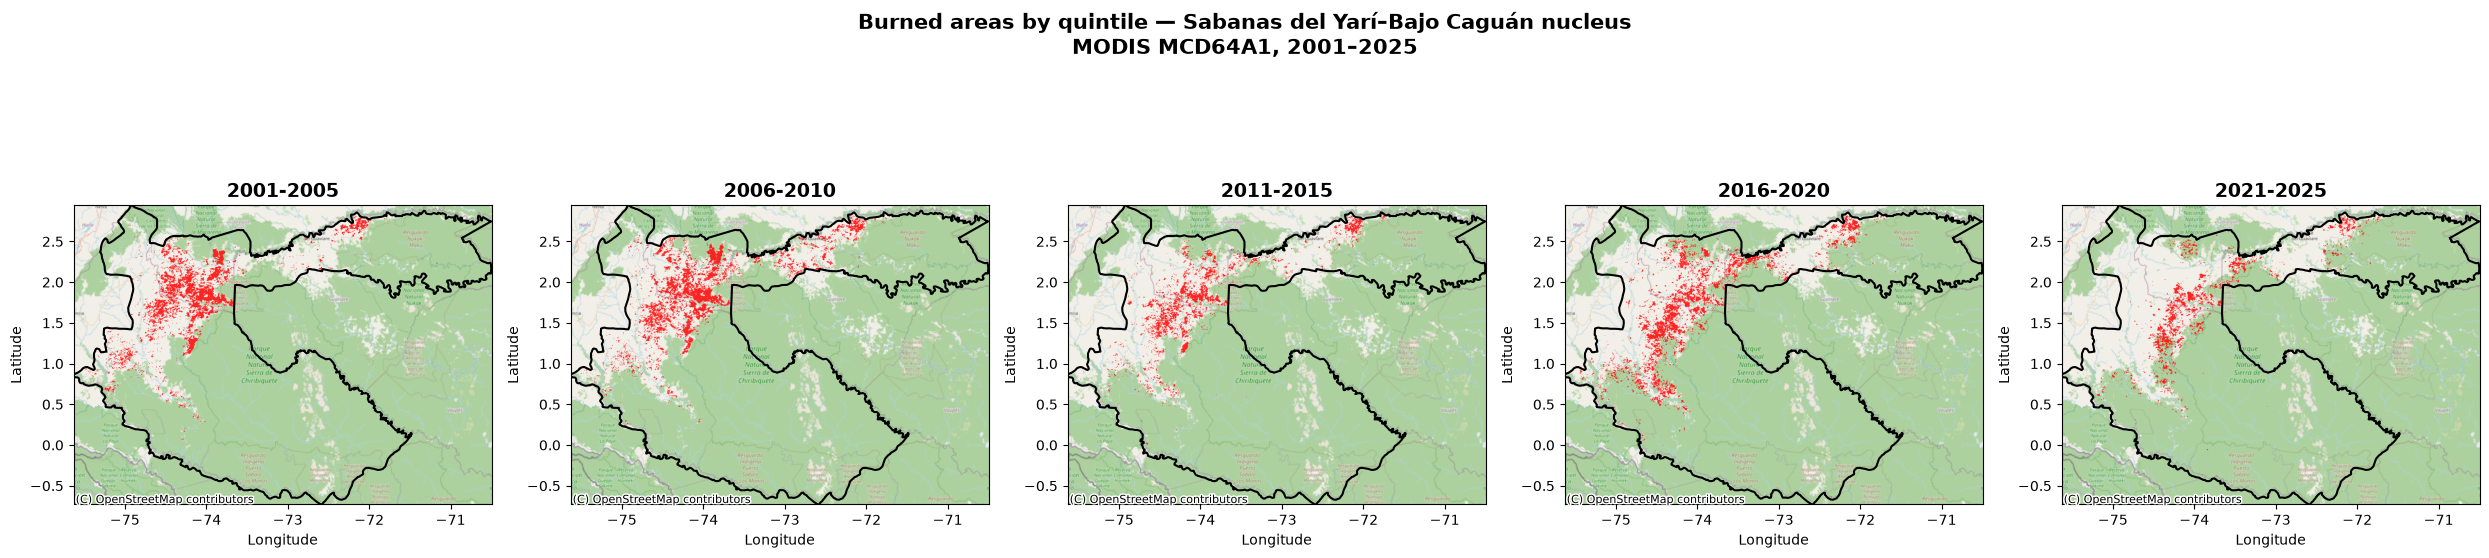


Facet plot with basemap generated.


In [10]:
# Facet plot of burned areas by quintile

import matplotlib.pyplot as plt
import contextily as cx
import requests
from PIL import Image
from io import BytesIO
import numpy as np

# visualization: burned pixels in bright red
vis_params = {
    'min': 0,
    'max': 1,
    'palette': ['FF0000']  # red for burned areas
}

# Bounding box of the nucleus
nucleus_bounds = nucleus_geom.bounds().getInfo()['coordinates'][0]
lon_min = min(p[0] for p in nucleus_bounds)
lon_max = max(p[0] for p in nucleus_bounds)
lat_min = min(p[1] for p in nucleus_bounds)
lat_max = max(p[1] for p in nucleus_bounds)

# Function to get image with transparency
def get_image_with_transparency(image, geometry, dimensions=800):
    """Gets image where unburned pixels are transparent."""
    url = image.getThumbURL({
        'region': geometry,
        'dimensions': dimensions,
        'format': 'png',
        'min': 0,
        'max': 1,
        'palette': ['FF0000']
    })
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert('RGBA')
    
    # make unburned pixels transparent
    data = np.array(img)
    # Pixels where there is no burn (near black/white) → transparent
    red, green, blue, alpha = data[:,:,0], data[:,:,1], data[:,:,2], data[:,:,3]
    # keep only red pixels (high R, low G and B)
    mask = (red > 150) & (green < 100) & (blue < 100)
    data[:,:,3] = np.where(mask, 255, 0)  # transparent where not red
    
    return Image.fromarray(data)

# Create the facet plot
fig, axes = plt.subplots(1, 5, figsize=(25, 6))

for ax, (label, mask) in zip(axes, quintile_masks.items()):
    print(f"Renderizing {label}...")
    
    # Get image with transparency
    img = get_image_with_transparency(mask, nucleus_geom)
    
    # Set the axis limits first
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    
    # add basemap of OpenStreetMap
    cx.add_basemap(
        ax,
        crs='EPSG:4326',
        source=cx.providers.OpenStreetMap.Mapnik,
        zoom=8
    )
    
    # overlay the burned area image
    ax.imshow(
        img,
        extent=[lon_min, lon_max, lat_min, lat_max],
        alpha=0.85,
        zorder=10
    )
    
    # add the border of the nucleus
    nucleus_coords = nucleus_geom.coordinates().getInfo()
    # handle MultiPolygon geometries
    if isinstance(nucleus_coords[0][0][0], list):
        for polygon in nucleus_coords:
            for ring in polygon:
                xs = [p[0] for p in ring]
                ys = [p[1] for p in ring]
                ax.plot(xs, ys, color='black', linewidth=1.5, zorder=11)
    else:
        for ring in nucleus_coords:
            xs = [p[0] for p in ring]
            ys = [p[1] for p in ring]
            ax.plot(xs, ys, color='black', linewidth=1.5, zorder=11)
    
    ax.set_title(label, fontsize=14, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.suptitle(
    'Burned areas by quintile — Sabanas del Yarí–Bajo Caguán nucleus\n'
    'MODIS MCD64A1, 2001–2025',
    fontsize=15, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('burned_area_quintiles_basemap.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nFacet plot with basemap generated.")

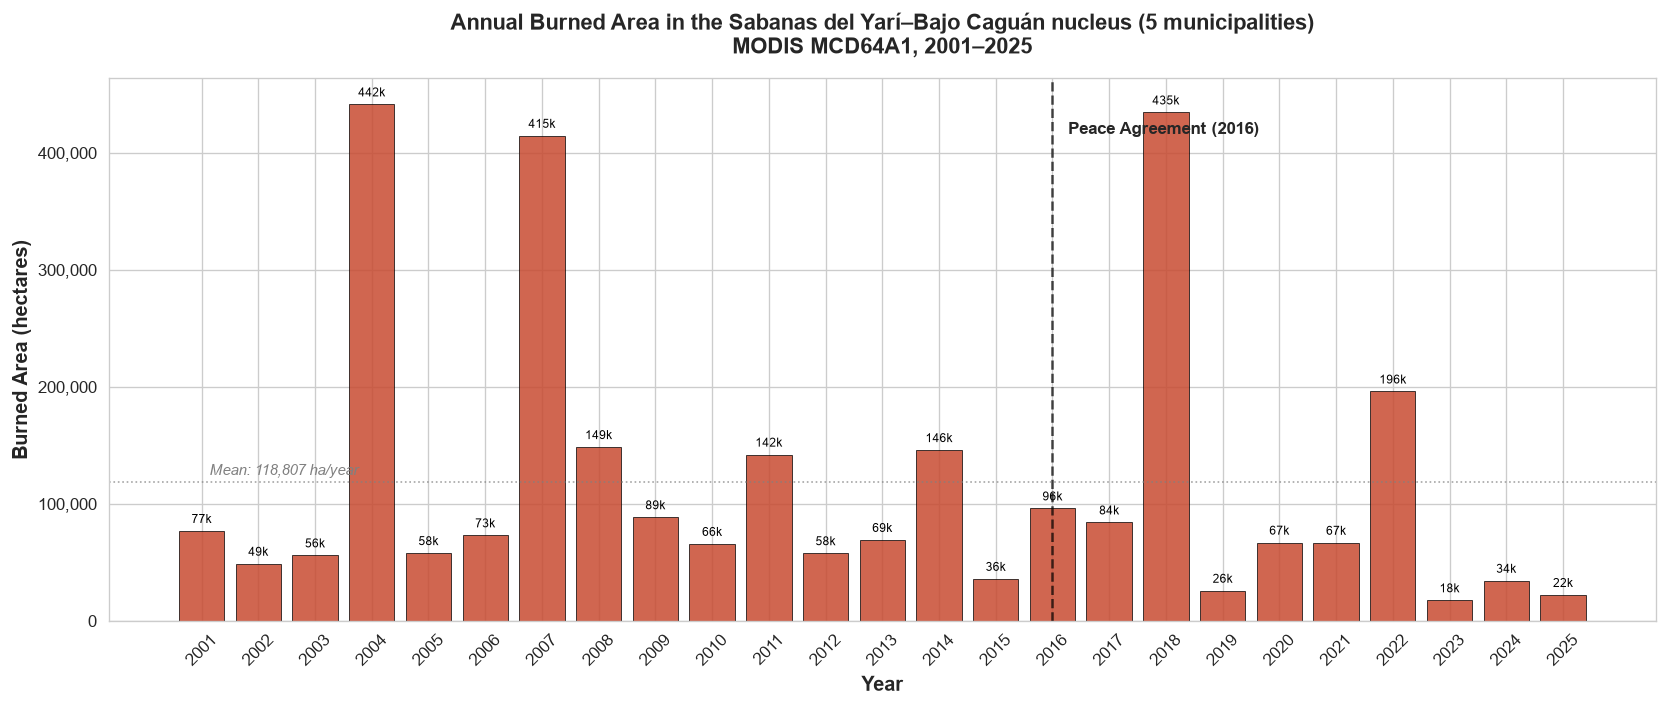


Time series plot generated.
Total burned area 2001-2025: 2,970,176 ha
Mean annual burned area: 118,807 ha
Max year: 2004 (441,597 ha)
Min year: 2023 (17,725 ha)


In [12]:
# Time series plot of annual burned area

import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120

# Create the time series plot
fig, ax = plt.subplots(figsize=(14, 6))

# Bar plot of annual burned area
bars = ax.bar(
    burned_df['year'], 
    burned_df['burned_area_ha'],
    color='#C84B31',
    edgecolor='black',
    linewidth=0.5,
    alpha=0.85
)

# Highlight the Peace Agreement year (2016) with a vertical line
ax.axvline(x=2016, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(2016.1, ax.get_ylim()[1]*0.92, '  Peace Agreement (2016)', 
        fontsize=10, fontweight='bold', verticalalignment='top')

# Compute the average burned area for reference
mean_burned = burned_df['burned_area_ha'].mean()
ax.axhline(y=mean_burned, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.text(2001, mean_burned*1.05, f'  Mean: {mean_burned:,.0f} ha/year', 
        fontsize=9, color='gray', fontstyle='italic')

# Labels and title
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Burned Area (hectares)', fontsize=12, fontweight='bold')
ax.set_title(
    'Annual Burned Area in the Sabanas del Yarí–Bajo Caguán nucleus (5 municipalities)\n'
    'MODIS MCD64A1, 2001–2025',
    fontsize=13, fontweight='bold', pad=15
)

# Format y-axis with thousand separators
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# X-axis ticks every year
ax.set_xticks(burned_df['year'])
plt.xticks(rotation=45)

# Add value labels on top of each bar (optional, can be removed if too cluttered)
for bar, value in zip(bars, burned_df['burned_area_ha']):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2., 
        height + (ax.get_ylim()[1] * 0.01),
        f'{value/1000:.0f}k',
        ha='center', va='bottom',
        fontsize=7, color='black'
    )

plt.tight_layout()
plt.savefig('annual_burned_area_timeseries.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nTime series plot generated.")
print(f"Total burned area 2001-2025: {burned_df['burned_area_ha'].sum():,.0f} ha")
print(f"Mean annual burned area: {mean_burned:,.0f} ha")
print(f"Max year: {burned_df.loc[burned_df['burned_area_ha'].idxmax(), 'year']} "
      f"({burned_df['burned_area_ha'].max():,.0f} ha)")
print(f"Min year: {burned_df.loc[burned_df['burned_area_ha'].idxmin(), 'year']} "
      f"({burned_df['burned_area_ha'].min():,.0f} ha)")